# Versuch 2

In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.color import rgb2gray
from pathlib import Path

## Aufgabe 1

### Zuerst Das Bild einlesen, croppen dessen Graustufen isolieren und deren Mittelwerte und Standardabweichungen berechnen.

13, 15, 18, 21, 27, 36, 78, 98, 117, 118, 119, 120, 121, 122, 123, 124, 125, 254, 255, 256, 257, 258, 259, 389, 390, 391, 392, 393, 521, 522, 523, 524, 525, 526, 
Mittelwerte: [ 38.08623737  73.27277132 116.52790698 157.39053478 204.77597656]
Standardabweichungen: [29.56909766 26.76378418 20.66961711 15.82072792 15.18066255]


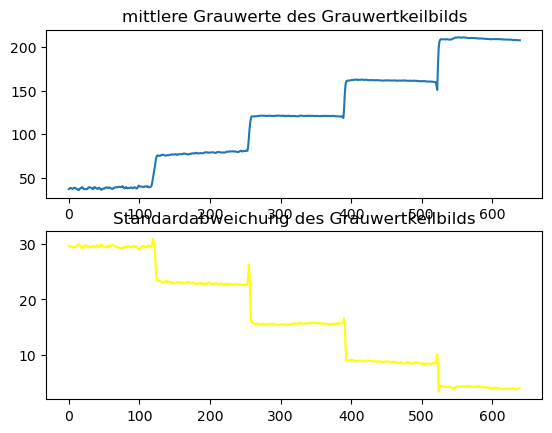

In [25]:

#gw = cv2.imread("./grauwertkeil.png")
img = cv2.imread("./versuch2-1_2.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

g = np.zeros((gray.shape[1]), dtype=float)
g_mean = np.zeros(5, dtype=float)
g_std = np.zeros(5, dtype=float)
std_gray = np.zeros((gray.shape[1]), dtype=float)

fig, splt = plt.subplots(2)
gw = 0
for i in range(0,gray.shape[1]):
    g[i] = np.mean(gray[:,i])
    std_gray[i] = np.std(gray[:,i])
    if i > 0 and abs(g[i-1] - g[i]) > 1:
        print(i, end=", ")

splt[0].plot(range(0,g.size),g)
splt[1].plot(range(0,std_gray.size),std_gray, color='yellow')
splt[0].set_title("mittlere Grauwerte des Grauwertkeilbilds")
splt[1].set_title("Standardabweichung des Grauwertkeilbilds")
cv2.waitKey(0)
cv2.destroyAllWindows()

g_mean[0] = np.mean(gray[:,0:99])
g_mean[1] = np.mean(gray[:,106:235])
g_mean[2] = np.mean(gray[:,242:371])
g_mean[3] = np.mean(gray[:,378:505])
g_mean[4] = np.mean(gray[:,512:gray.shape[1]])

g_std[0] = np.std(gray[:,0:99])
g_std[1] = np.std(gray[:,106:235])
g_std[2] = np.std(gray[:,242:371])
g_std[3] = np.std(gray[:,378:505])
g_std[4] = np.std(gray[:,512:gray.shape[1]])

print(f"\nMittelwerte: {g_mean}")
print(f"Standardabweichungen: {g_std}")

## Aufgabe 2

### Alle Schwarzbilder einlesen und sie in Graubilder übersetzen.

0 544
0 545
0 546


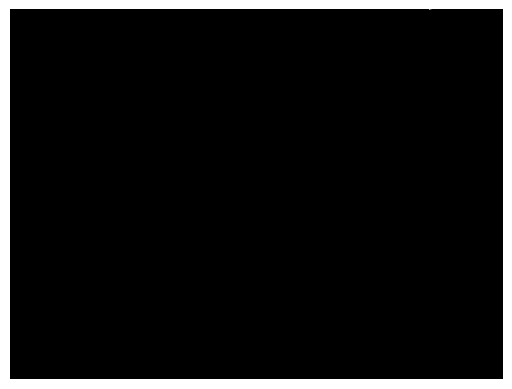

hellster Punkt: 0 544


In [26]:
blackGVal = []
def contrast(arr): return ((arr - np.min(arr)) / abs(np.max(arr) - np.min(arr))) * 255
for i in range(0, 10):
    img = cv2.imread(f"./schwarz{i}.png")
    blackG = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(float)
    blackGVal.append(blackG)

blackGV = np.array(blackGVal)
mean_white = np.full(shape=(blackGV.shape[1], blackGV.shape[2]), fill_value=100, dtype=float)
for i in range(0, blackGV.shape[1]):
    for j in range(0, blackGV.shape[2]):
        mean_white[i,j] = np.mean(blackGV[:,i,j])
n = contrast(mean_white)
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if mean_white[i,j] > 0: print(i, j)
plt.imshow(contrast(mean_white), cmap='gray',vmax=255,vmin=0)
cv2.imwrite("./mvpblack.png", mean_white)
plt.axis('off')
plt.show()
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if n[i,j] == 255: print("hellster Punkt:", i, j)
mvpb = mean_white

### Liest Dunkelbild ein, subtahiert von einem Eingabebild und gibt das korrigierte Bild aus.

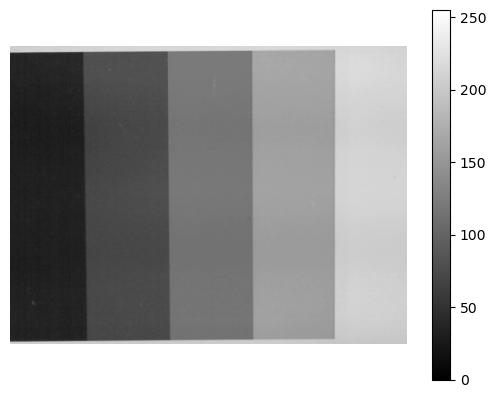

In [27]:
def DarkSubtractPic(picArr):
    black = cv2.cvtColor(cv2.imread(f"./mvpblack.png"), cv2.COLOR_BGR2GRAY)
    out = picArr - black
    cv2.imwrite('./DarkSubtractPic.png', out)
    return out
#plt.imshow(gray, cmap='gray',vmax=255,vmin=0)
plt.imshow(DarkSubtractPic(gray),vmax=255,vmin=0, cmap='gray')

plt.axis('off')
plt.colorbar()
plt.show()

## Aufgabe 3

### 10 Weißbilder einlesen, ihren Mittelwert berechnen, und davon das Dunkelbild berechnen.

170.9
196.8


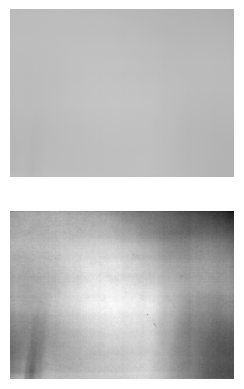

dunkelster Punkt: 0 629


In [28]:
whiteGVal = []

for i in range(0, 10):
    img = cv2.imread(f"./white_{i}.png")
    whiteG = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)
    whiteGVal.append(whiteG)

whiteGV = np.array(whiteGVal)
mean_white = np.full(shape=(whiteGV.shape[1], whiteGV.shape[2]), fill_value=100, dtype=np.float64)
for i in range(0, whiteGV.shape[1]):
    for j in range(0, whiteGV.shape[2]):
        mean_white[i, j] = np.mean(whiteGV[:, i, j])
fig, splts = plt.subplots(2)
mean_white = DarkSubtractPic(mean_white)
mean_norm = contrast(mean_white)
cv2.imwrite("./mvpwhite.png", mean_white)
print(np.min(mean_white))
print(np.max(mean_white))
splts[0].imshow(mean_white, cmap='gray',vmax=255,vmin=0, )
splts[1].imshow(mean_norm, cmap='gray')
splts[0].axis('off')
splts[1].axis('off')
plt.show()
cv2.imwrite("./pic.png", mean_norm)
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        #if mean_norm[i,j] == 255: print("hellster Punkt:", i, j)
        if mean_norm[i,j] == 0: print("dunkelster Punkt:", i, j)

### Normierung mit Weißbild

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

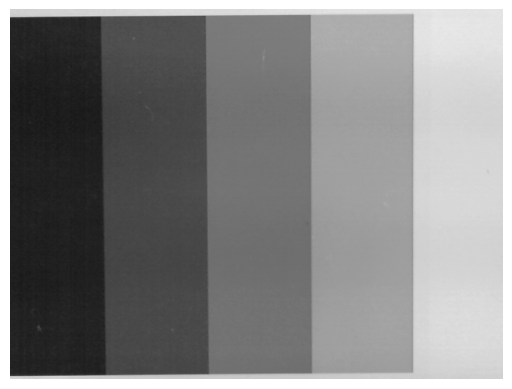

In [29]:
def wNorm(arr):
    normed_white = cv2.cvtColor(cv2.imread("./mvpwhite.png"), cv2.COLOR_BGR2GRAY).astype(np.float64)
    normed_white /= np.mean(normed_white)
    out = DarkSubtractPic(arr) / normed_white
    cv2.imwrite("./wNorm.png", out)
    return out
plt.imshow(wNorm(gray), cmap='gray',vmax=255,vmin=0, )
plt.axis('off')

## Aufgabe 4 - Pixelfehler

In [30]:
n = mvpb
for i in range(0, n.shape[0]):
    for j in range(0, n.shape[1]):
        if n[i,j] > 0: print("Hot- oder stuckpixel:", i, j)



Hot- oder stuckpixel: 0 544
Hot- oder stuckpixel: 0 545
Hot- oder stuckpixel: 0 546


## Anwendung Grauwertkeil

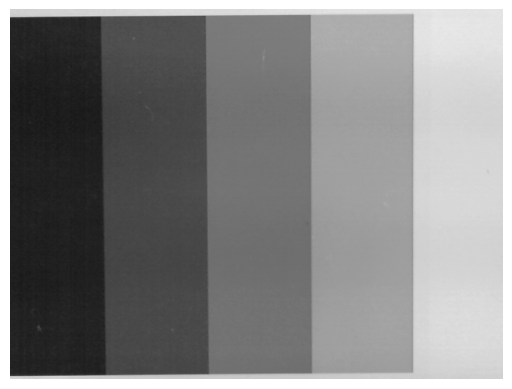

In [31]:
cgwk = wNorm(gray)
cv2.imwrite("./correctedGWK.png", cgwk)
plt.imshow(cgwk, cmap='gray',vmax=255,vmin=0)
plt.axis('off')
plt.show()

## Means und Stds

In [ ]:
g_mean_corr = np.zeros(5, dtype=float)
g_std_corr = np.zeros(5, dtype=float)
g_mean_corr[0] = np.mean(cgwk[:,0:99])
g_mean_corr[1] = np.mean(cgwk[:,106:235])
g_mean_corr[2] = np.mean(cgwk[:,242:371])
g_mean_corr[3] = np.mean(cgwk[:,378:505])
g_mean_corr[4] = np.mean(cgwk[:,512:gray.shape[1]])

g_std_corr[0] = np.std(cgwk[:,0:99])
g_std_corr[1] = np.std(cgwk[:,106:235])
g_std_corr[2] = np.std(cgwk[:,242:371])
g_std_corr[3] = np.std(cgwk[:,378:505])
g_std_corr[4] = np.std(cgwk[:,512:gray.shape[1]])

print(g_mean_corr)
print(g_std_corr)


[ 38.34914633  72.44177601 114.33941032 157.69399189 210.49752314]
[29.73576874 26.74522639 21.08229589 17.19757482 16.41796723]


ValueError: operands could not be broadcast together with shapes (5,) (640,) 

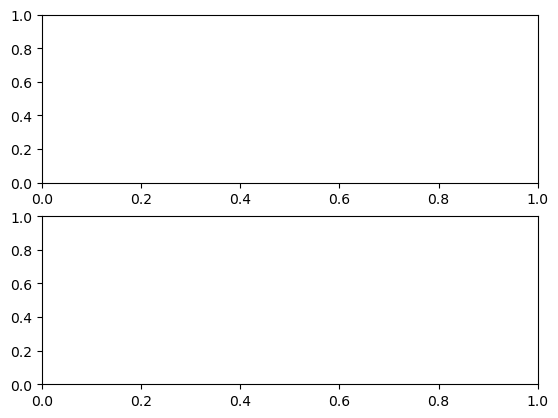

In [23]:
fig, splt = plt.subplots(2)
gw = 0
cgv = np.full((gray.shape[1]), 0, dtype=float)
for i in range(0,gray.shape[1]):
    cgv[i] = np.mean(cgwk[:,i])
    std_gray[i] = np.std(cgwk[:,i])
diffs = g_std - std_gray
print(f"Unterschied durch Korrektur: {diffs}")
splt[0].plot(range(0,g.size),cgv)
splt[1].plot(range(0,std_gray.size),std_gray, color='yellow')
splt[0].set_title("mittlere Grauwerte des Grauwertkeilbilds")
splt[1].set_title("Standardabweichung des Grauwertkeilbilds")